In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import figure
from wordcloud import WordCloud

In [10]:
df=pd.read_csv('cleaned_fake_job_postings.csv')
df

,Unnamed: 0,job_id,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,function,fraudulent,text
0,0,1,False,True,False,other,Junior,NaN,Business,False,marketing intern food52 created groundbreaking...
1,1,2,False,True,False,Full-time,NaN,NaN,Business,False,customer service cloud video production 90 se...
2,2,3,False,True,False,NaN,NaN,NaN,NaN,False,commissioning machinery assistant cma valor se...
3,3,4,False,True,False,Full-time,Standard,Undergraduate,Business,False,account executive washington dc passion impro...
4,4,5,False,True,True,Full-time,Standard,Undergraduate,Healthcare,False,bill review manager spotsource solution llc gl...
...,...,...,...,...,...,...,...,...,...,...,...
17875,17875,17876,False,True,True,Full-time,Standard,NaN,Business,False,account director distribution vend looking aw...
17876,17876,17877,False,True,True,Full-time,Standard,Undergraduate,Finance,False,payroll accountant weblinc e-commerce platform...
17877,17877,17878,False,False,False,Full-time,NaN,NaN,NaN,False,project cost control staff engineer cost cont...
17878,17878,17879,False,False,True,other,NaN,other,Design,False,graphic designer nemsia studio looking experie...


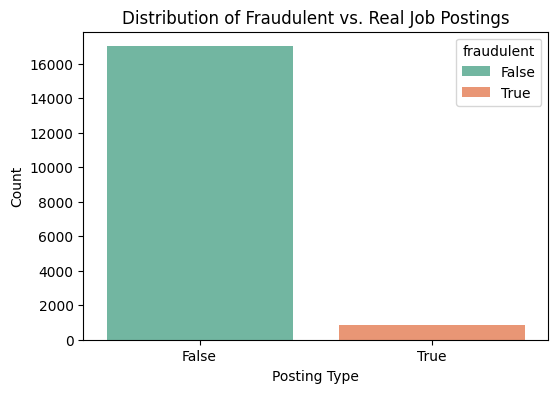

In [11]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="fraudulent", hue='fraudulent',data=df, palette="Set2")
plt.title("Distribution of Fraudulent vs. Real Job Postings")
plt.xlabel("Posting Type")
plt.ylabel("Count")
plt.show()


In [12]:
df["employment_type"].value_counts()


employment_type
Full-time    11620
other         1992
Part-time      797
Name: count, dtype: int64

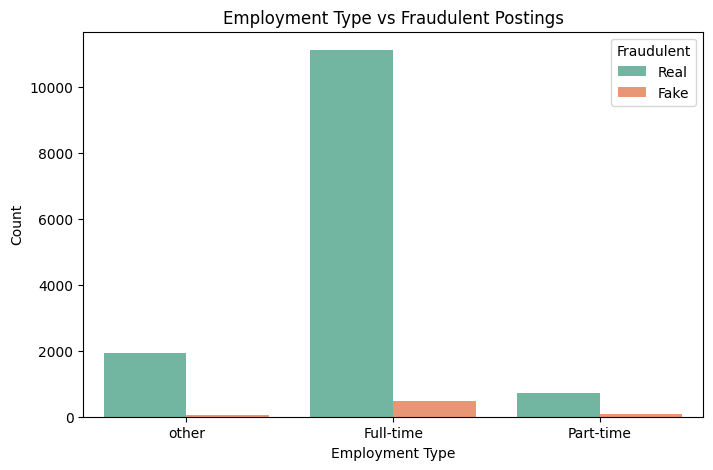

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="employment_type", data=df, hue="fraudulent", palette="Set2")
plt.title("Employment Type vs Fraudulent Postings")
plt.ylabel("Count")
plt.xlabel("Employment Type")
plt.legend(title="Fraudulent", labels=["Real", "Fake"])
plt.show()

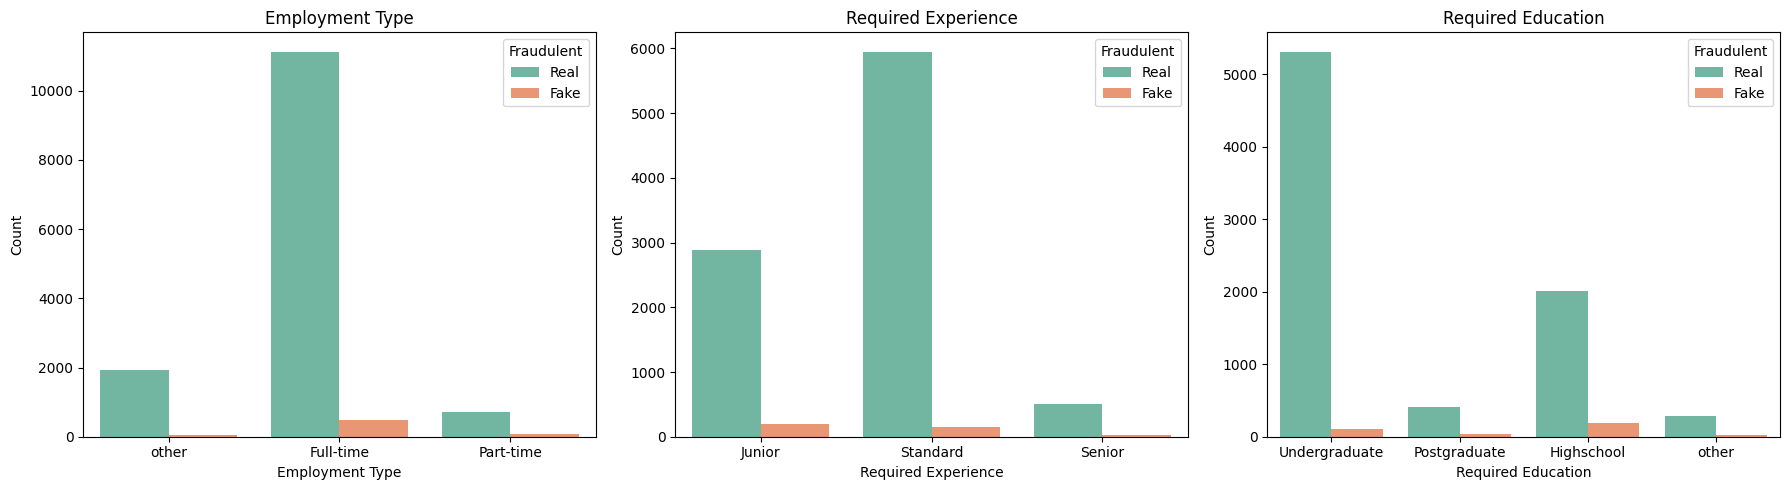

In [19]:
# Create figure with 3 subplots horizontally
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, columns, titles):
    sns.countplot(
        x=col,
        hue="fraudulent",
        data=df,
        palette="Set2",
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(col.replace("_"," ").title())
    ax.set_ylabel("Count")
    #ax.set_xticklabels(["No","Yes"])
    ax.legend(title="Fraudulent", labels=["Real","Fake"])

plt.tight_layout()
plt.show()

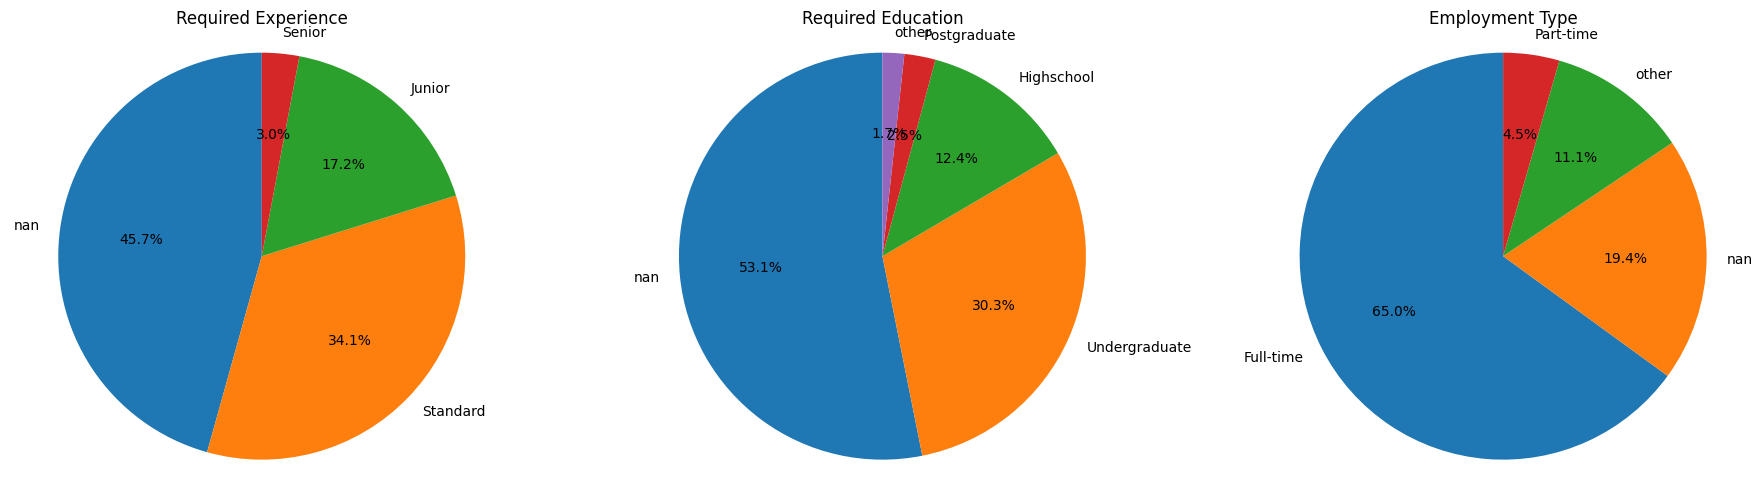

In [15]:
columns = ["required_experience", "required_education", "employment_type"]
titles = [
    "Required Experience",
    "Required Education",
    "Employment Type"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, columns, titles):
    counts = df[col].value_counts(dropna=False)
    
    labels = [str(label) for label in counts.index]
    sizes = counts.values

    ax.pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(title)
    ax.axis("equal")  # Keep it circular

plt.tight_layout()
plt.show()


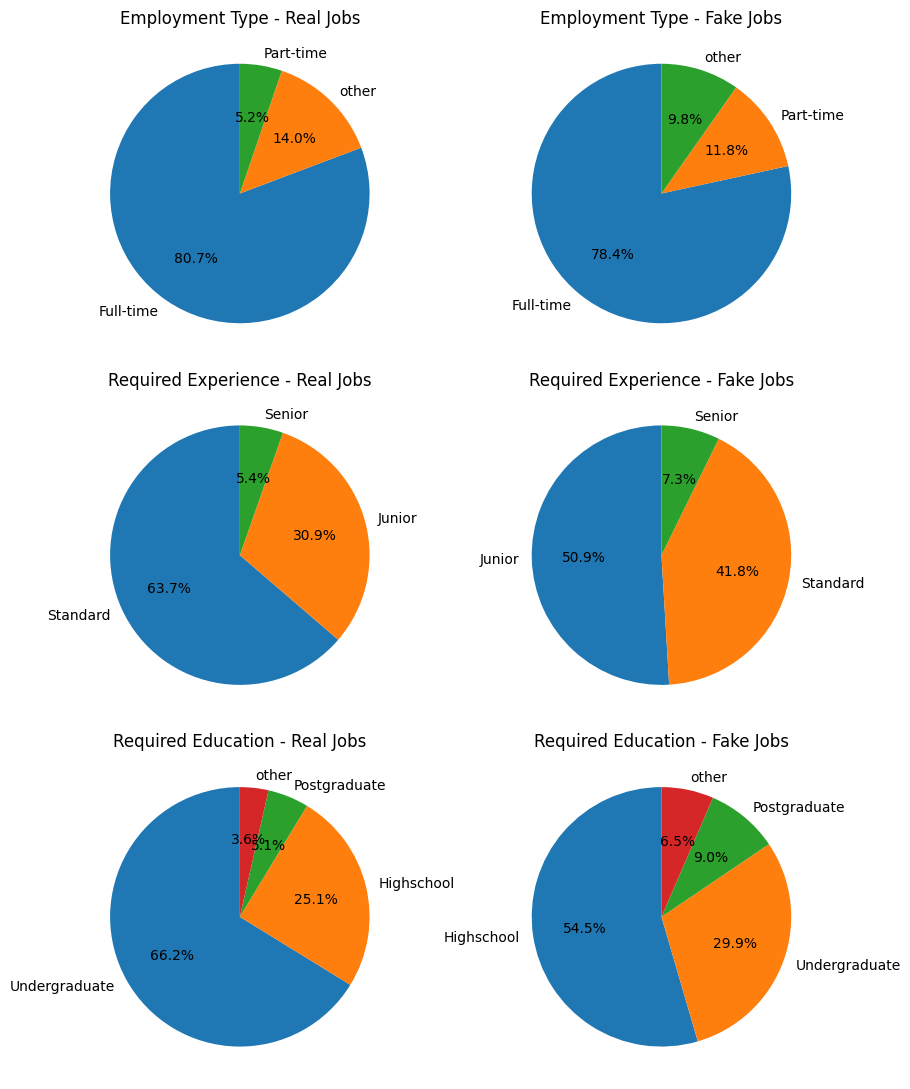

In [16]:
import matplotlib.pyplot as plt

# Subset the data
real = df[df["fraudulent"] == 0]
fake = df[df["fraudulent"] == 1]

columns = ["employment_type", "required_experience", "required_education"]
titles = ["Employment Type", "Required Experience", "Required Education"]

# Define bright colors
custom_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# Create figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(9, 11))  # smaller height

for row_idx, (col, title) in enumerate(zip(columns, titles)):
    # Real postings pie
    counts_real = real[col].value_counts()
    axes[row_idx, 0].pie(
        counts_real.values,
        labels=counts_real.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=custom_colors
    )
    axes[row_idx, 0].set_title(f"{title} - Real Jobs")

    # Fake postings pie
    counts_fake = fake[col].value_counts()
    axes[row_idx, 1].pie(
        counts_fake.values,
        labels=counts_fake.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=custom_colors
    )
    axes[row_idx, 1].set_title(f"{title} - Fake Jobs")

plt.tight_layout()
plt.show()


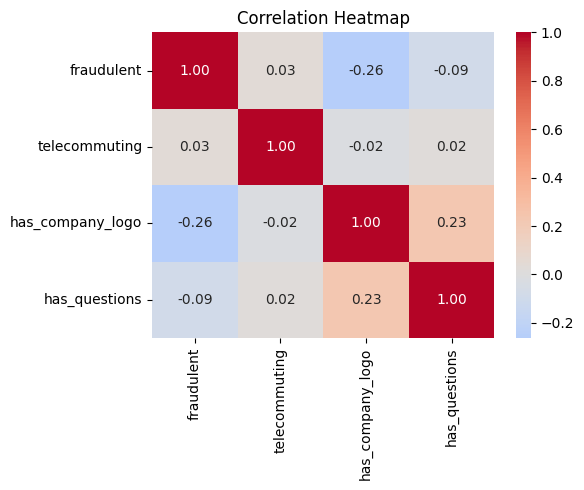

In [17]:
# Select numeric columns
numeric_cols = ["fraudulent", "telecommuting", "has_company_logo", "has_questions"]

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Text analysis

In [18]:
# Create two strings, one containing all the words in real posts and the other fake posts 
real_data = df.loc[df["fraudulent"] == False,]
fake_data = df.loc[df["fraudulent"] == True,]
real_text = " ".join(real_data["text"])
fake_text = " ".join(fake_data["text"])

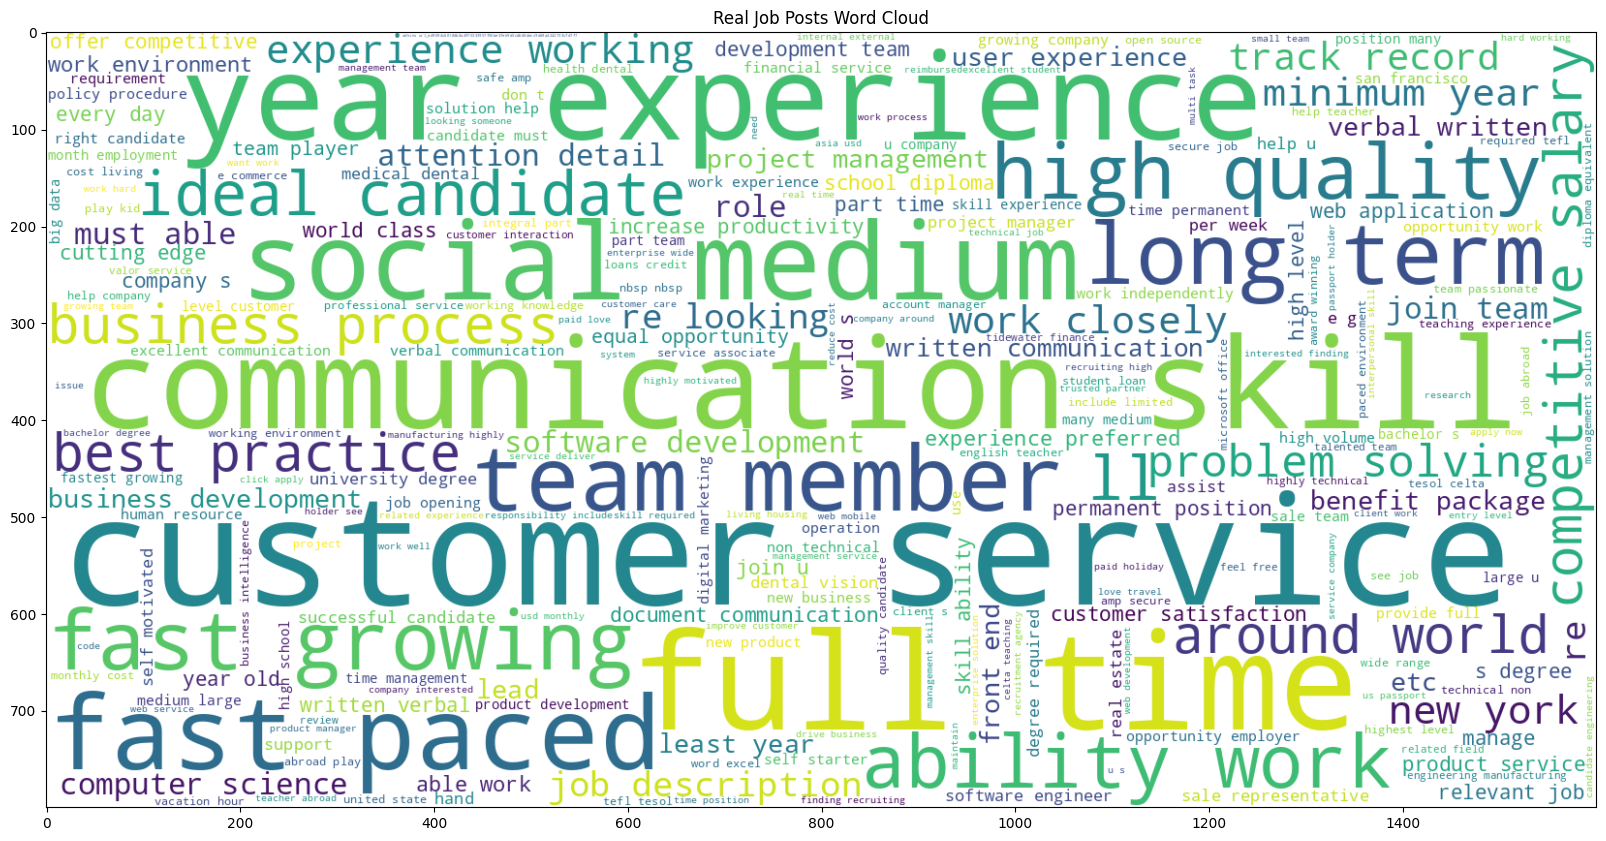

In [23]:
# Create a word cloud of words in real posts
plt.figure(figsize = (20,20))

word_cloud = WordCloud(width = 1600 , height = 800 , max_words = 1000, background_color="white").generate(real_text)
plt.imshow(word_cloud, interpolation = 'bilinear')
plt.title("Real Job Posts Word Cloud")
plt.show()

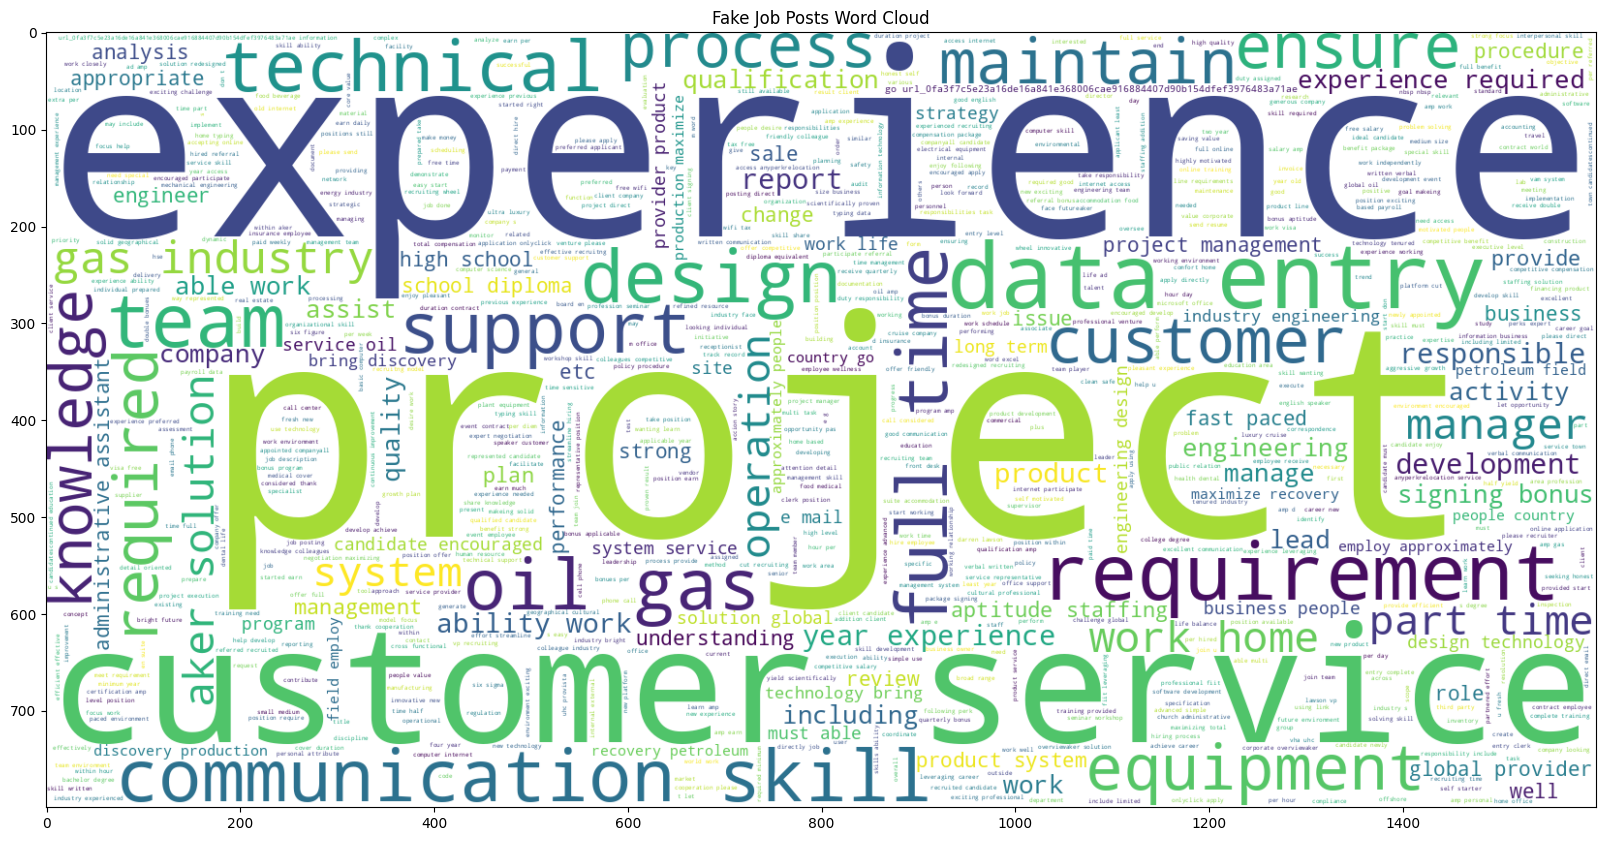

In [24]:
# Create a word cloud of words in fake posts
plt.figure(figsize = (20,20))

word_cloud = WordCloud(width = 1600 , height = 800 , max_words = 1000, background_color="white").generate(fake_text)
plt.imshow(word_cloud, interpolation = 'bilinear')
plt.title("Fake Job Posts Word Cloud")
plt.show()

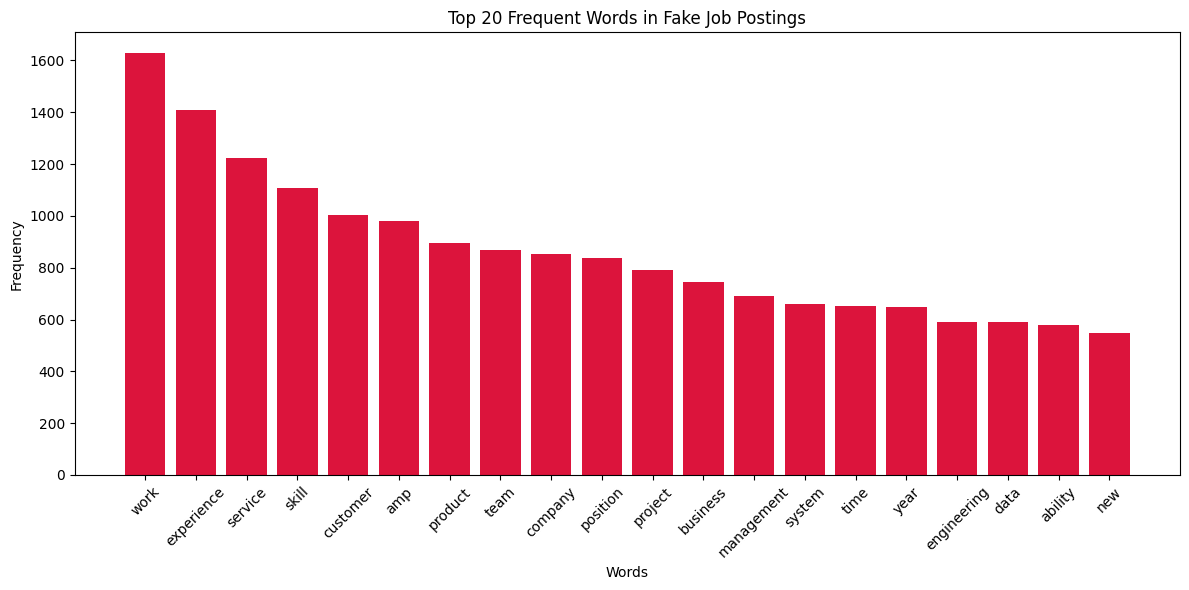

In [28]:
from collections import Counter
import matplotlib.pyplot as plt

# Filter only fraudulent job postings
fake_texts = df[df["fraudulent"] == 1]["text"]

# Split all words in fake job texts
all_words = " ".join(fake_texts).split()

# Count frequency of each word
word_freq = Counter(all_words)

# Get the 20 most common words
common_words = word_freq.most_common(20)

# Split into two lists for plotting
words, counts = zip(*common_words)

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='crimson')
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words in Fake Job Postings")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [33]:
jobs =pd.read_csv('fake_job_postings.csv')


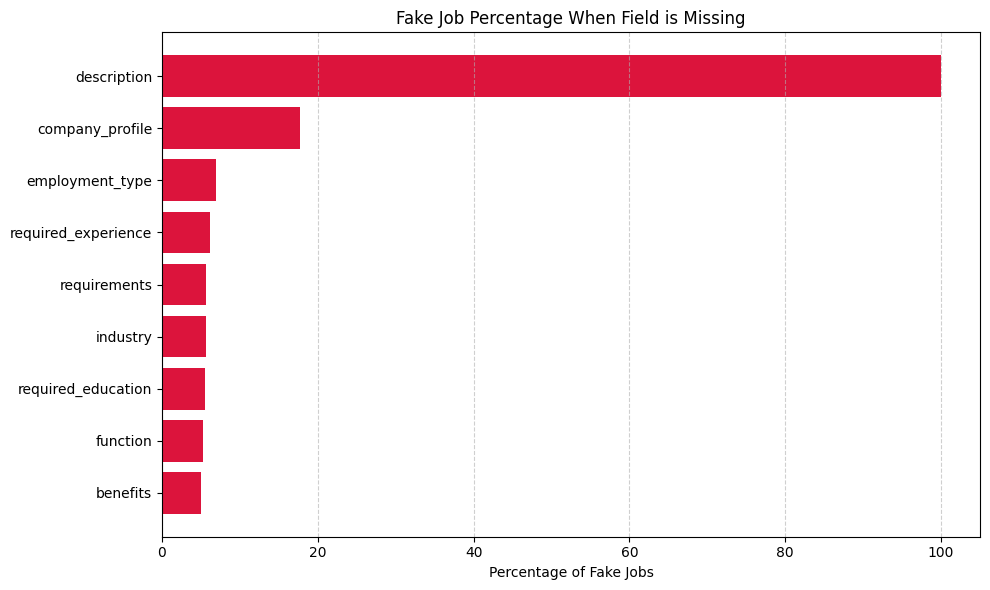

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

important_fields = [
    "company_profile", "description", "requirements", "benefits",
    "employment_type", "required_experience", "required_education",
    "industry", "function"
]

fraud_percent_when_missing = {}

for col in important_fields:
    missing_rows = jobs[jobs[col].isnull()]
    total_missing = len(missing_rows)
    if total_missing == 0:
        fraud_percent_when_missing[col] = 0
    else:
        fake_count = missing_rows["fraudulent"].sum()
        fraud_percent_when_missing[col] = (fake_count / total_missing) * 100

# Convert to Series and sort
fraud_percent_series = pd.Series(fraud_percent_when_missing).sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10,6))
plt.barh(fraud_percent_series.index, fraud_percent_series.values, color="crimson")
plt.xlabel("Percentage of Fake Jobs")
plt.title("Fake Job Percentage When Field is Missing")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
